In [ ]:
# 1. Import Libraries

#1. Data Handling Libraries
import pandas as pd #used to read and manage the EEG dataset (CSV files, tables).
import numpy as np #used for numerical operations such as arrays and mathematical calculations.

#2. Visualization Libraries
import matplotlib.pyplot as plt #used to create graphs and plots.
import seaborn as sns #used to generate advanced statistical visualizations.

#3. Preprocessing Libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
#LabelEncoder converts categorical values into numeric form.
#StandardScaler normalizes the data so all features have similar scale.

#4. Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif
#SelectKBest selects the most important features from the dataset.
#f_classif is a statistical test used to measure how strongly features relate to the target variable.

#5. Data Splitting & Optimization
from sklearn.model_selection import train_test_split, RandomizedSearchCV
#train_test_split divides the dataset into:Training data,Testing data
#RandomizedSearchCV is used to optimize model parameters automatically.

#6. Machine Learning Models
from sklearn.ensemble import RandomForestClassifier #reduces overfitting
from xgboost import XGBClassifier #improves accuracy.

#7. Evaluation Metrics
from sklearn.metrics import accuracy_score, classisfication_report, confusion_matrix

#8. Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
#If some neurological disorder classes have fewer samples, SMOTE creates synthetic samples to balance the dataset.

#9. Deep Learning Libraries
from tensorflow.keras.models import Sequential
#These are used to build an Artificial Neural Network (ANN).
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

#10.Label Conversion
from tensorflow.keras.utils import to_categorical
#Used to convert labels into categorical format for neural network training.

#11.Training Optimization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Model Saving
import joblib #saves trained models and preprocessing objects.

#12. File Handling
import os #manages file paths and directories.

## Data Preprocessing

In [ ]:
# 2. Load and Clean Dataset
df = pd.read_csv("EEG_dataset.csv")

# Drop irrelevant columns
df.drop(columns=['eeg.date'], errors='ignore', inplace=True)

# Drop rows with missing target values
df.dropna(subset=['main.disorder'], inplace=True)

# Drop columns with all missing values
df.dropna(axis=1, how='all', inplace=True)

# Fill missing numeric values with median to handle outliers better
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Encode categorical variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'].astype(str))

#Encode Target Variable
le_target = LabelEncoder()
df['main.disorder'] = le_target.fit_transform(df['main.disorder'].astype(str))
print("Target Mapping:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Drop non-numeric columns
non_numeric = df.select_dtypes(include=['object']).columns
df.drop(columns=non_numeric, inplace=True)

Target Mapping: {'Addictive disorder': np.int64(0), 'Anxiety disorder': np.int64(1), 'Healthy control': np.int64(2), 'Mood disorder': np.int64(3), 'Obsessive compulsive disorder': np.int64(4), 'Schizophrenia': np.int64(5), 'Trauma and stress related disorder': np.int64(6)}


## Exploratory Data Analysis

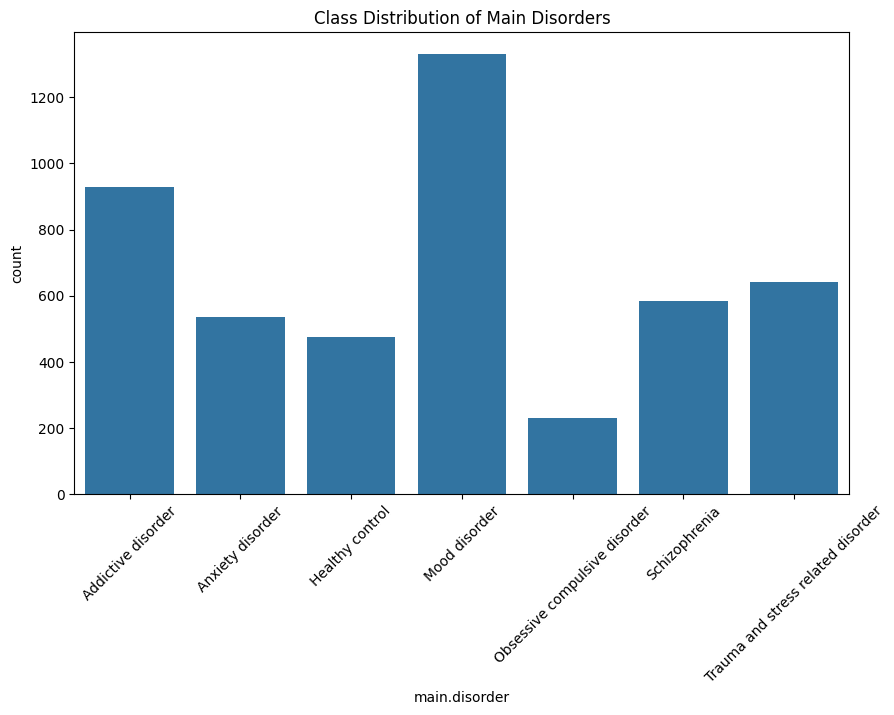

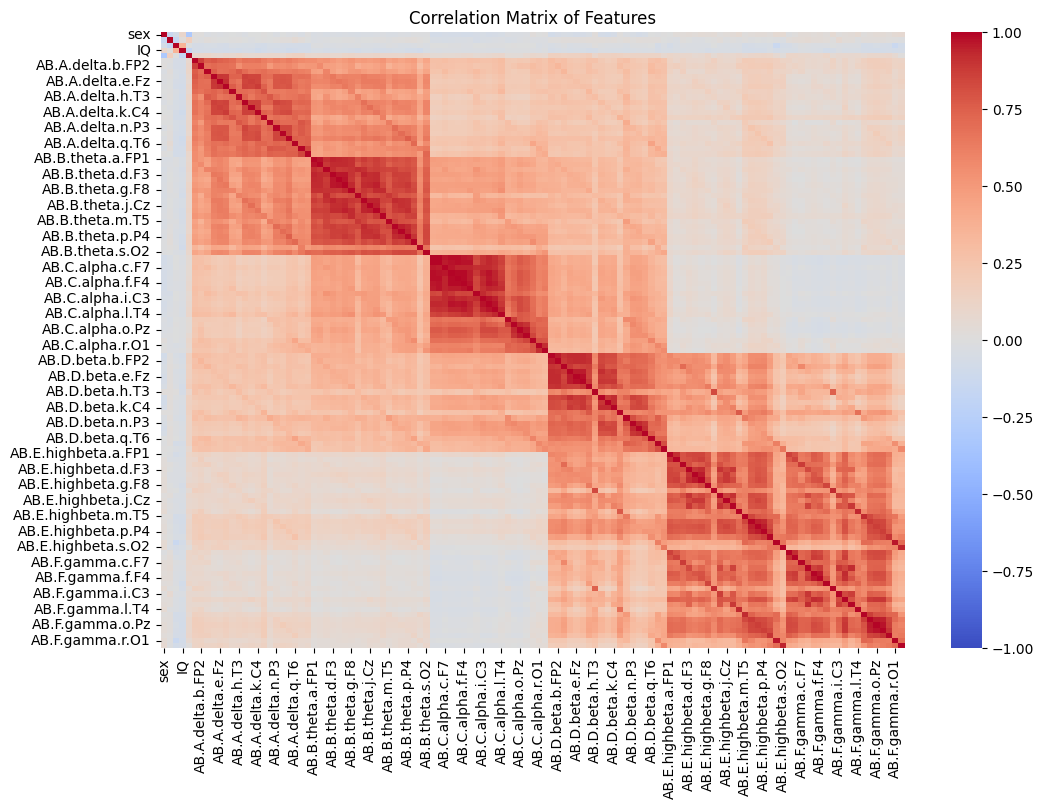

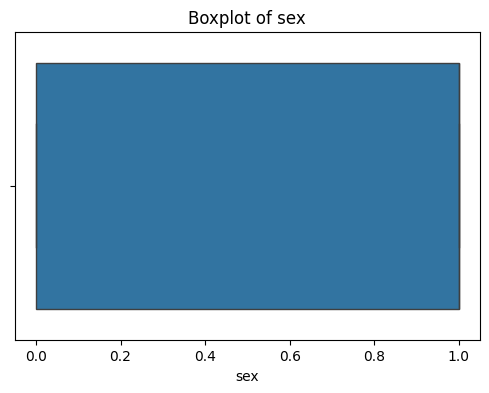

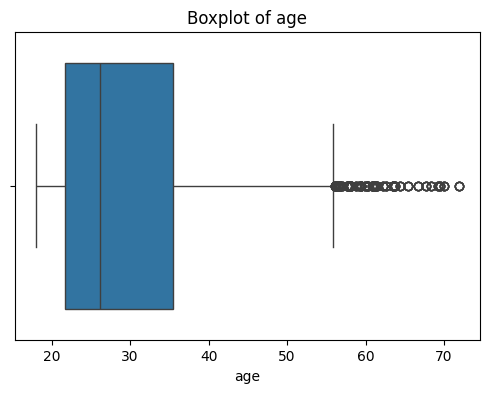

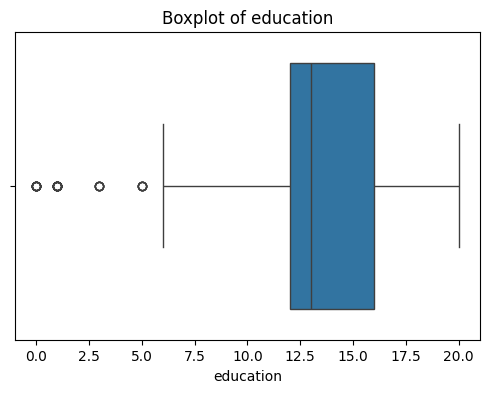

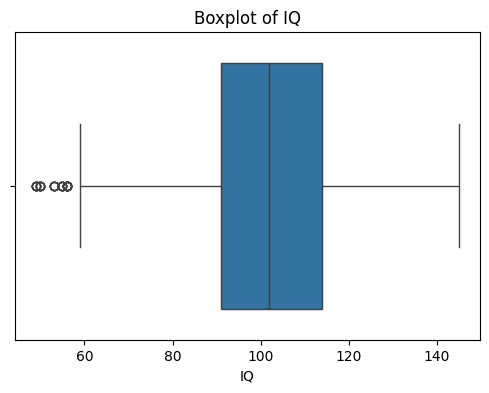

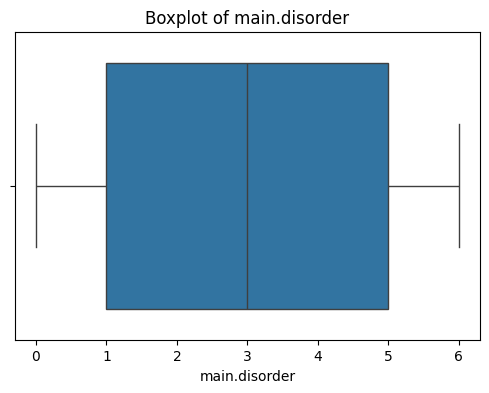

In [ ]:
# 3. Exploratory Data Analysis
# Check class distribution

#We visualize the distribution of different neurological disorders to check if the dataset is balanced.
plt.figure(figsize=(10, 6))
sns.countplot(x='main.disorder', data=df)
plt.title("Class Distribution of Main Disorders")
plt.xticks(ticks=range(len(le_target.classes_)), labels=le_target.classes_, rotation=45)
plt.show()

# Correlation matrix to identify highly correlated features
#We analyze the correlation between features to understand relationships and detect redundant features.
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Features")
plt.show()

# Check for outliers using boxplots for a few features
for col in df.columns[:5]:  # Visualize first 5 numeric columns
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [9]:
# 4. Feature Processing and Selection
X = df.drop(columns=['main.disorder'])
y = df['main.disorder']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Select top features (increase k to retain more features)
selector = SelectKBest(score_func=f_classif, k=10)  # Increased from 100 to 150
X_selected = selector.fit_transform(X_scaled, y)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_selected, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

## Random Forest Classifier

Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}
Random Forest Accuracy: 0.9962406015037594
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       266
           1       1.00      0.99      1.00       266
           2       1.00      1.00      1.00       266
           3       1.00      1.00      1.00       266
           4       0.99      1.00      1.00       266
           5       1.00      1.00      1.00       266
           6       0.99      1.00      0.99       266

    accuracy                           1.00      1862
   macro avg       1.00      1.00      1.00      1862
weighted avg       1.00      1.00      1.00      1862



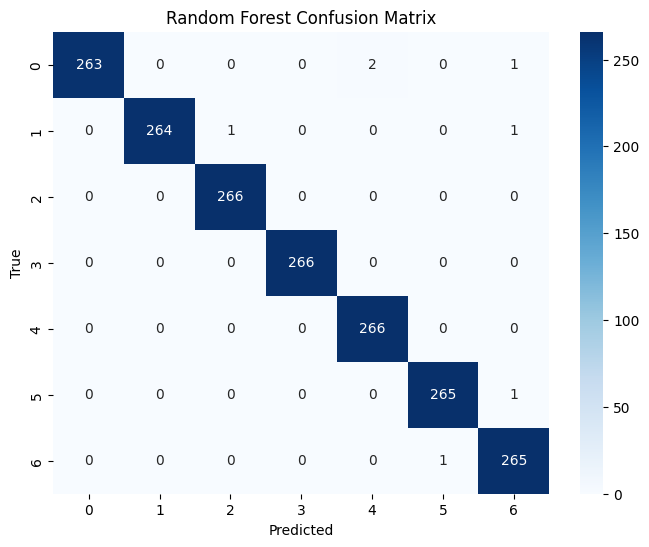

In [ ]:
# 5.1 Random Forest Classifier with Hyperparameter Tuning

#Defining Hyperparameters for Random Forest
rf_params = {
    'n_estimators': [100, 200, 300, 500],#number of trees
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

#Creating the Random Forest Model
rf = RandomForestClassifier(random_state=42)

#Hyperparameter Tuning using RandomizedSearchCV
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
#We use RandomizedSearchCV with cross-validation to efficiently find the best hyperparameters.


#Training the Model
rf_search.fit(X_train, y_train)

#Getting the Best Model
best_rf = rf_search.best_estimator_

#Making Predictions
y_pred_rf = best_rf.predict(X_test)

print("Best Random Forest Parameters:", rf_search.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## XGBoost Classifier

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\1052\.conda\envs\env5\lib\site-packages\xgboost\training.py:183: UserWarning: [17:35:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best XGBoost Parameters: {'subsample': 1.0, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
🎯 XGBoost Accuracy: 0.9758324382384532
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       266
           1       0.99      0.97      0.98       266
           2       0.98      1.00      0.99       266
           3       0.97      0.96      0.96       266
           4       0.99      0.99      0.99       266
           5       0.97      0.98      0.97       266
           6       0.98      0.96      0.97       266

    accuracy                           0.98      1862
   macro avg       0.98      0.98      0.98      1862
weighted avg       0.98      0.98      0.98      1862



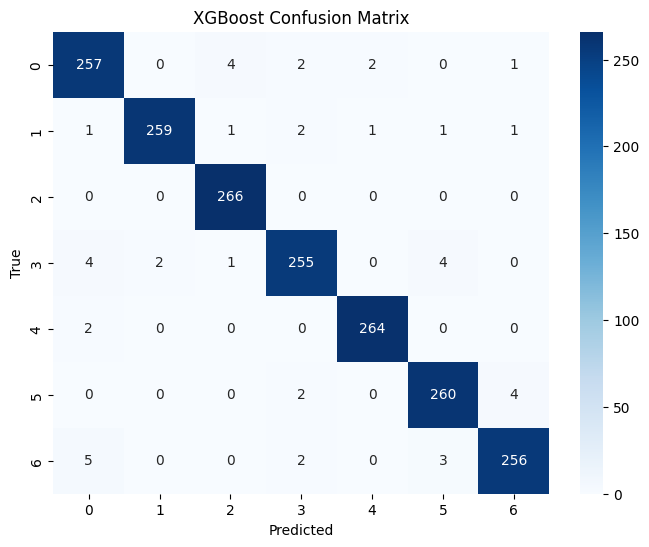

In [11]:
# 5.2 Quick XGBoost Classifier Tuning (≈1 minute)

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

xgb_params = {
    'n_estimators': [50, 100, 150],          # Reduced range
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_params,
    n_iter=5,             # Faster search
    cv=5,                 # Faster cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1             # Show progress
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("✅ Best XGBoost Parameters:", xgb_search.best_params_)
print("🎯 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## Deep Learning Model

c:\Users\1052\.conda\envs\env5\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2677 - loss: 2.0618 - val_accuracy: 0.3369 - val_loss: 1.7322 - learning_rate: 0.0010
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3206 - loss: 1.7778 - val_accuracy: 0.4262 - val_loss: 1.5499 - learning_rate: 0.0010
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3409 - loss: 1.6758 - val_accuracy: 0.4779 - val_loss: 1.4533 - learning_rate: 0.0010
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3662 - loss: 1.6069 - val_accuracy: 0.5013 - val_loss: 1.3891 - learning_rate: 0.0010
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3877 - loss: 1.5656 - val_accuracy: 0.5081 - val_loss: 1.3529 - learning_rate: 0.0010
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3996 - loss: 1.5248 - val_accuracy: 0.5195 - val_loss: 1.3124 - learning_rate: 0.0010
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4240 - loss: 1.

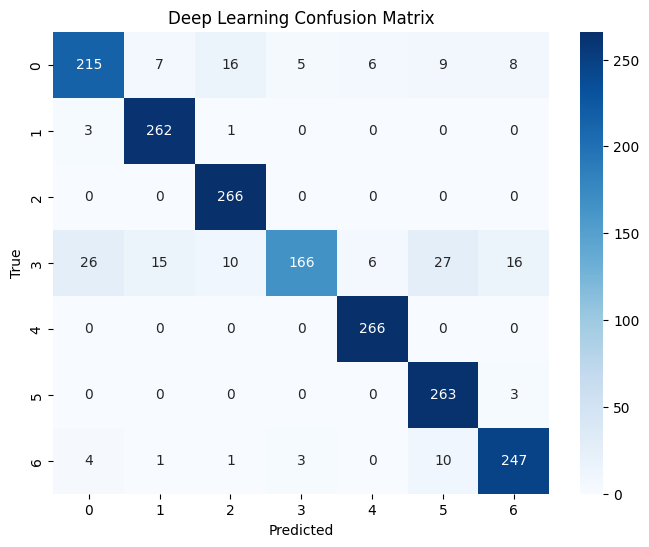

In [12]:
# 5.3 Deep Learning Model
y_train_dl = to_categorical(y_train)
y_test_dl = to_categorical(y_test)
input_dim = X_train.shape[1]
output_dim = y_train_dl.shape[1]

dl_model = Sequential([
    Dense(256, input_dim=input_dim, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(output_dim, activation='softmax')
])

dl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train model
dl_model.fit(X_train, y_train_dl, epochs=100, batch_size=32, verbose=1, 
             validation_split=0.2, callbacks=[early_stopping, lr_reducer])

# Evaluate model
dl_eval = dl_model.evaluate(X_test, y_test_dl, verbose=0)
print("Deep Learning Accuracy:", dl_eval[1])

# Confusion Matrix
y_pred_dl = np.argmax(dl_model.predict(X_test), axis=1)
y_test_classes = np.argmax(y_test_dl, axis=1)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_classes, y_pred_dl), annot=True, fmt='d', cmap='Blues')
plt.title("Deep Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

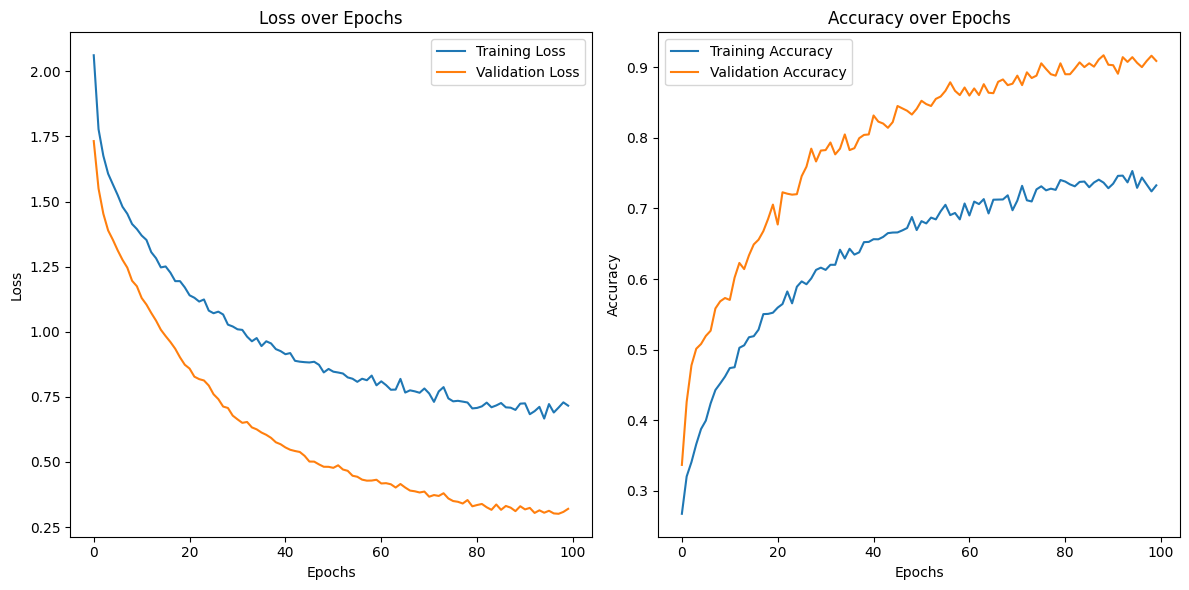

In [16]:
import matplotlib.pyplot as plt

# Assuming your model is already trained and stored in 'dl_model'

# Training history for visualization
history = dl_model.history.history

# Plotting loss curves
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Compare Model Performance

Model Performance Summary:
Random Forest Accuracy: 0.9962
XGBoost Accuracy: 0.9758
Deep Learning Accuracy: 0.9049


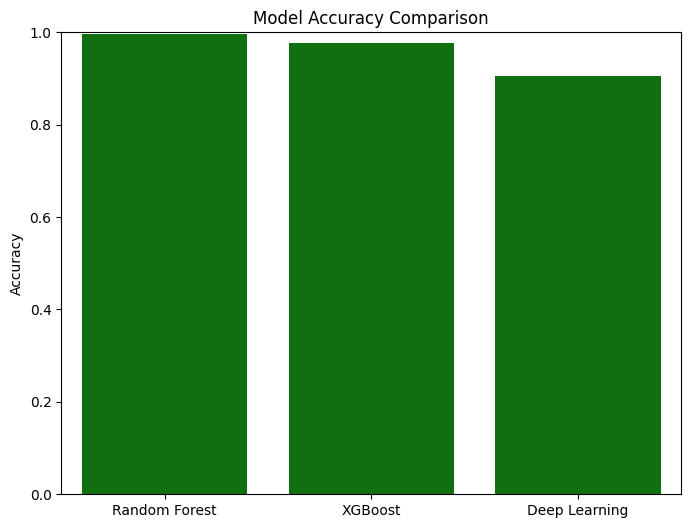

In [13]:
# 6. Compare Model Performance
print("Model Performance Summary:")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Deep Learning Accuracy: {dl_eval[1]:.4f}")

# Plot accuracy comparison
models = ['Random Forest', 'XGBoost', 'Deep Learning']
accuracies = [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb), dl_eval[1]]
plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies, color="green")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

##  Save Models

In [14]:
# 7. Save Models
os.makedirs("eeg_saved_models", exist_ok=True)
joblib.dump(best_rf, "eeg_saved_models/rf_model.pkl")
joblib.dump(best_xgb, "eeg_saved_models/xgb_model.pkl")
dl_model.save("eeg_saved_models/dl_model.keras")  # Use .keras format
print("Models saved in 'eeg_saved_models/'")

Models saved in 'eeg_saved_models/'
